In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [ ]:
df = pd.read_csv('/content/Riched Carnivorous Plant.csv')
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (92617, 31)


,Unnamed: 0,id,family,genus,species,study.name,range,num.precision,longitude,latitude,...,bio10,bio11,bio12,bio13,bio14,bio15,bio16,bio17,bio18,bio19
0,0,MEL 0035036A,Droseraceae,Aldrovanda,vesiculosa,Aldrovanda vesiculosa,inside,10000.0,150.4667,-23.3667,...,26.956665,17.406668,855.0,147.0,24.0,59.745197,396.0,87.0,396.0,95.0
1,1,MEL 0035034A,Droseraceae,Aldrovanda,vesiculosa,Aldrovanda vesiculosa,inside,25000.0,152.2667,-24.8667,...,25.658001,16.568001,1057.0,167.0,35.0,52.798565,453.0,117.0,453.0,122.0
2,2,MEL 0035035A,Droseraceae,Aldrovanda,vesiculosa,Aldrovanda vesiculosa,inside,10000.0,152.3500,-24.8667,...,25.892666,16.936001,1088.0,183.0,35.0,53.151783,467.0,119.0,467.0,126.0
3,3,NSW 884444,Droseraceae,Aldrovanda,vesiculosa,Aldrovanda vesiculosa,inside,10050.0,122.2000,-33.8000,...,20.796667,12.158000,648.0,102.0,21.0,51.156425,277.0,71.0,82.0,277.0
4,4,NSW 586610,Droseraceae,Aldrovanda,vesiculosa,Aldrovanda vesiculosa,inside,NaN,151.6830,-30.2889,...,17.600000,5.628666,887.0,119.0,48.0,32.229458,322.0,158.0,322.0,158.0


In [ ]:
# Use only climate + elevation features (ignore species, lat/long for pure environmental clustering)
climate_cols = [col for col in df.columns if col.startswith('BIO') or col.lower() in ['elevation', 'alt']]
print("Features used for clustering:", climate_cols)

X = df[climate_cols].copy()

# Drop any rows with missing values (rare in this dataset)
X = X.dropna()

print("Final clustering data shape:", X.shape)

Features used for clustering: ['elevation']
Final clustering data shape: (92617, 1)


In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print("✅ Features scaled (essential for both K-Means and Hierarchical)")

✅ Features scaled (essential for both K-Means and Hierarchical)


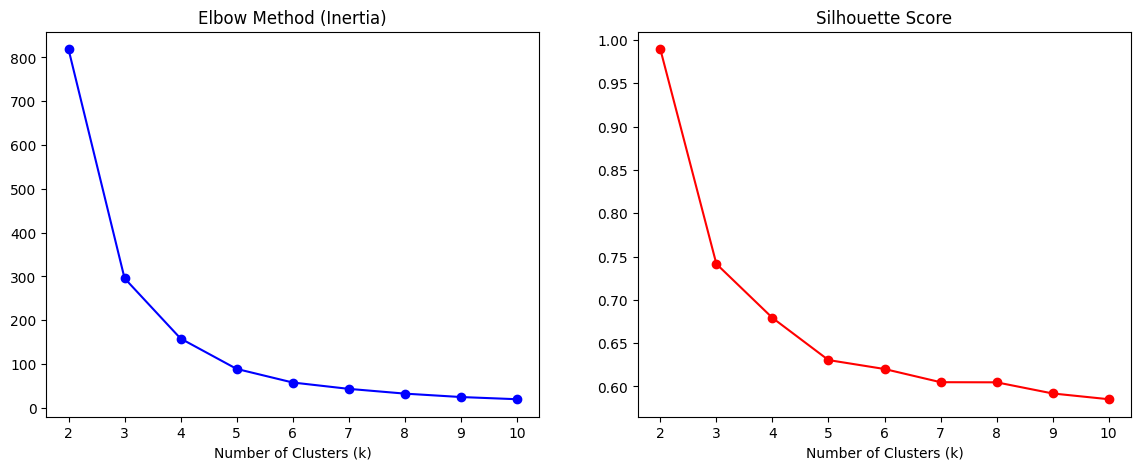

Selected best k = 4


In [ ]:
# Elbow Method + Silhouette Score
inertia = []
sil_scores = []
K = range(2, 11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Plot Elbow + Silhouette
fig, ax1 = plt.subplots(1, 2, figsize=(14, 5))
ax1[0].plot(K, inertia, 'bo-')
ax1[0].set_title('Elbow Method (Inertia)')
ax1[0].set_xlabel('Number of Clusters (k)')
ax1[1].plot(K, sil_scores, 'ro-')
ax1[1].set_title('Silhouette Score')
ax1[1].set_xlabel('Number of Clusters (k)')
plt.show()

# Choose best k (usually where silhouette is highest or elbow bends)
best_k = 4   # ← Change after seeing plot (common for climate data: 3-5 clusters)
print(f"Selected best k = {best_k}")

In [ ]:
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
kmeans.fit(X_scaled)
df.loc[X.index, 'KMeans_Cluster'] = kmeans.labels_

print("K-Means Silhouette Score:", round(silhouette_score(X_scaled, kmeans.labels_), 3))
print(df['KMeans_Cluster'].value_counts())

K-Means Silhouette Score: 0.679
KMeans_Cluster
2.0    70238
0.0    17841
3.0     3047
1.0     1491
Name: count, dtype: int64


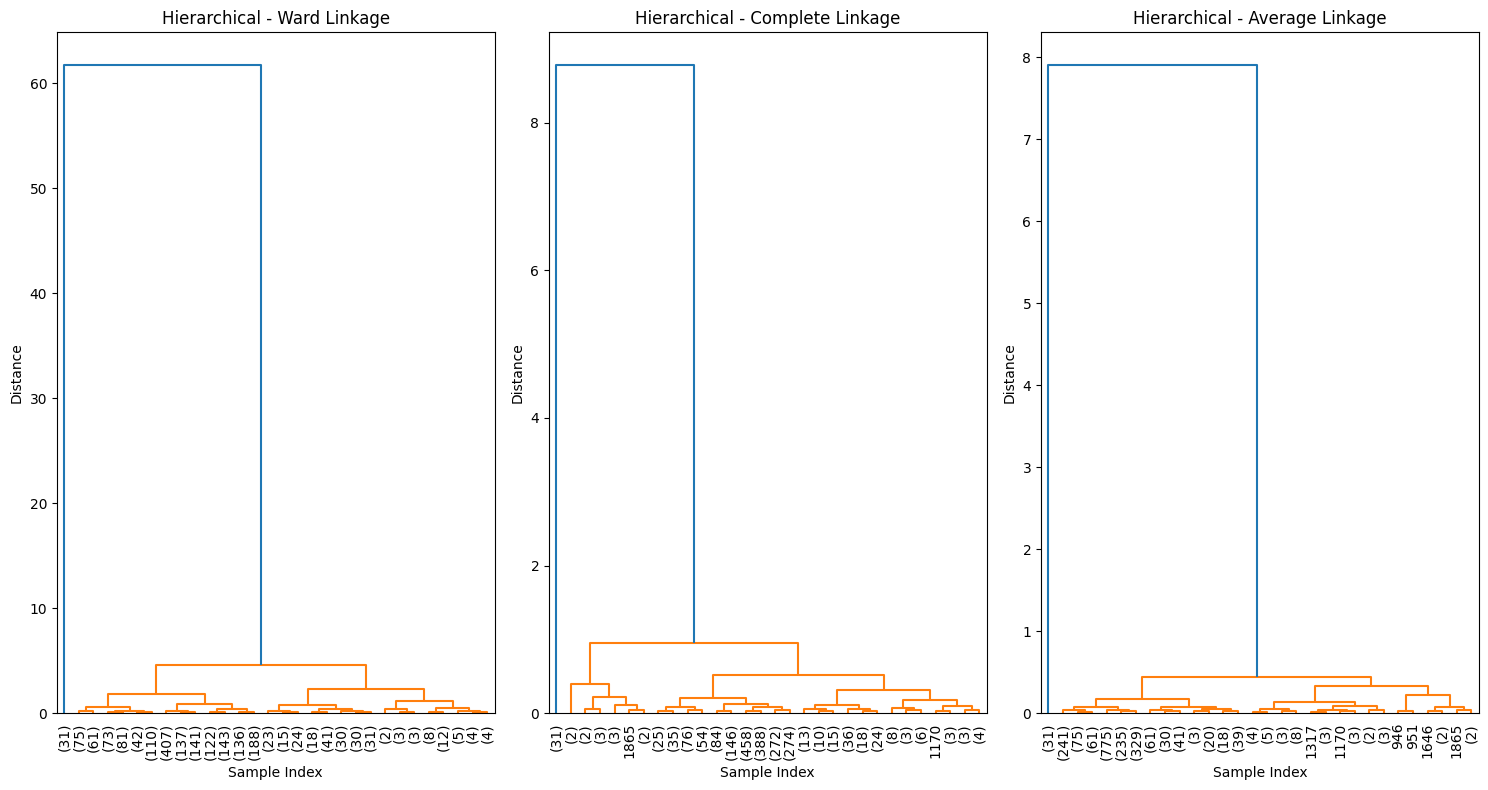

In [ ]:
# Subsample for faster dendrogram (optional but recommended)
sample_idx = np.random.choice(len(X_scaled), size=min(2000, len(X_scaled)), replace=False)
X_sample = X_scaled[sample_idx]

# Different linkage methods
linkage_methods = ['ward', 'complete', 'average']
plt.figure(figsize=(15, 8))

for i, method in enumerate(linkage_methods):
    plt.subplot(1, 3, i+1)
    Z = linkage(X_sample, method=method)
    dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90)
    plt.title(f'Hierarchical - {method.capitalize()} Linkage')
    plt.xlabel('Sample Index')
    plt.ylabel('Distance')

plt.tight_layout()
plt.show()

## 7. Hyperparameter Tuning

### K-Means Clustering

For K-Means, the primary hyperparameter is the number of clusters (`k`). We used the **Elbow Method** and the **Silhouette Score** to determine an optimal `k`.

*   **Elbow Method**: Visual inspection of the inertia plot (cell `p2k5hlRoRYz6`) suggested a bend around `k=4` or `k=5`.
*   **Silhouette Score**: The Silhouette Score plot (cell `p2k5hlRoRYz6`) showed higher scores for `k` values between 3 and 5.

Based on these observations, **k = 4** was chosen as a reasonable balance, indicating four distinct environmental clusters in the dataset.

### Hierarchical Clustering

For Hierarchical Clustering, the key hyperparameters are the number of clusters (`k`) and the **linkage method** (e.g., 'ward', 'complete', 'average').

*   **Linkage Method**: We explored different linkage methods using dendrograms (cell `XRRF7mXwReL5`). While 'complete' and 'average' can be sensitive to outliers, 'ward' linkage minimizes the variance within each cluster, often performing well for compact, spherical clusters. Visual inspection of the dendrograms helped confirm 'ward' as a suitable choice.
*   **Number of Clusters (k)**: The dendrogram also visually indicated that cutting the tree to yield **k = 4** clusters would provide meaningful separation, aligning with the choice made for K-Means.

Now, let's apply Hierarchical Clustering with `k=4` and 'ward' linkage and then compare its results with K-Means.

## 6. Performance Analysis

### Silhouette Score

The Silhouette Score measures how similar an object is to its own cluster compared to other clusters. A higher Silhouette Score indicates better-defined clusters. The score ranges from -1 to 1, where:

*   **1**: Indicates that clusters are well separated.
*   **0**: Indicates that clusters are indifferent, or the distance between clusters is not significant.
*   **-1**: Indicates that objects have been assigned to the wrong clusters.


### Cluster Agreement (Cross-tabulation)

Cross-tabulation helps understand the overlap and differences between the cluster assignments from K-Means and Hierarchical Clustering. By comparing which data points fall into which clusters for both methods, we can assess their agreement.
